2025-10-07 03:45:04.891627: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 03:45:05.013721: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 03:45:06.690128: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 03:45:07.370545: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到标准数据生成器。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']


2025-10-07 03:45:11.921075: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 03:45:13.333001: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:42] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-10-07 03:45:13.333120: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22152 MB memory:  -> device: 0, name: B1.gpu.large, pci bus id: 0000:36:00.0, compute capability: 8.6


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 96, 96, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 96, 96, 32)       128       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 96, 96, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 48, 48, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 48, 48, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        1

2025-10-07 03:45:17.137875: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-10-07 03:45:21.585350: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


383/383 [==============================] - ETA: 0s - loss: 5.4496 - accuracy: 0.3103 - precision: 0.3705 - recall: 0.1420
Epoch 1: val_accuracy improved from -inf to 0.38980, saving model to models/fer2013_best_model.h5

Epoch 1/100
训练: 损失=5.4496, 准确率=0.3103
训练: 精确率=0.3705, 召回率=0.1420
验证: 损失=4.9440, 准确率=0.3898
验证: 精确率=0.3898, 召回率=0.3898
验证: F1分数=0.3898
已用时: 0.63分钟, 预计剩余: 62.07分钟
当前学习率: 0.000500
383/383 [==============================] - 38s 75ms/step - loss: 5.4496 - accuracy: 0.3103 - precision: 0.3705 - recall: 0.1420 - val_loss: 4.9440 - val_accuracy: 0.3898 - val_precision: 0.3898 - val_recall: 0.3898 - lr: 5.0000e-04
Epoch 2/100
382/383 [============================>.] - ETA: 0s - loss: 4.2676 - accuracy: 0.3582 - precision: 0.4730 - recall: 0.1516
Epoch 2: val_accuracy improved from 0.38980 to 0.40164, saving model to models/fer2013_best_model.h5

Epoch 2/100
训练: 损失=4.2665, 准确率=0.3584
训练: 精确率=0.4732, 召回率=0.1517
验证: 损失=3.7032, 准确率=0.4016
验证: 精确率=0.4785, 召回率=0.3579
验证: F1分数=0.4095


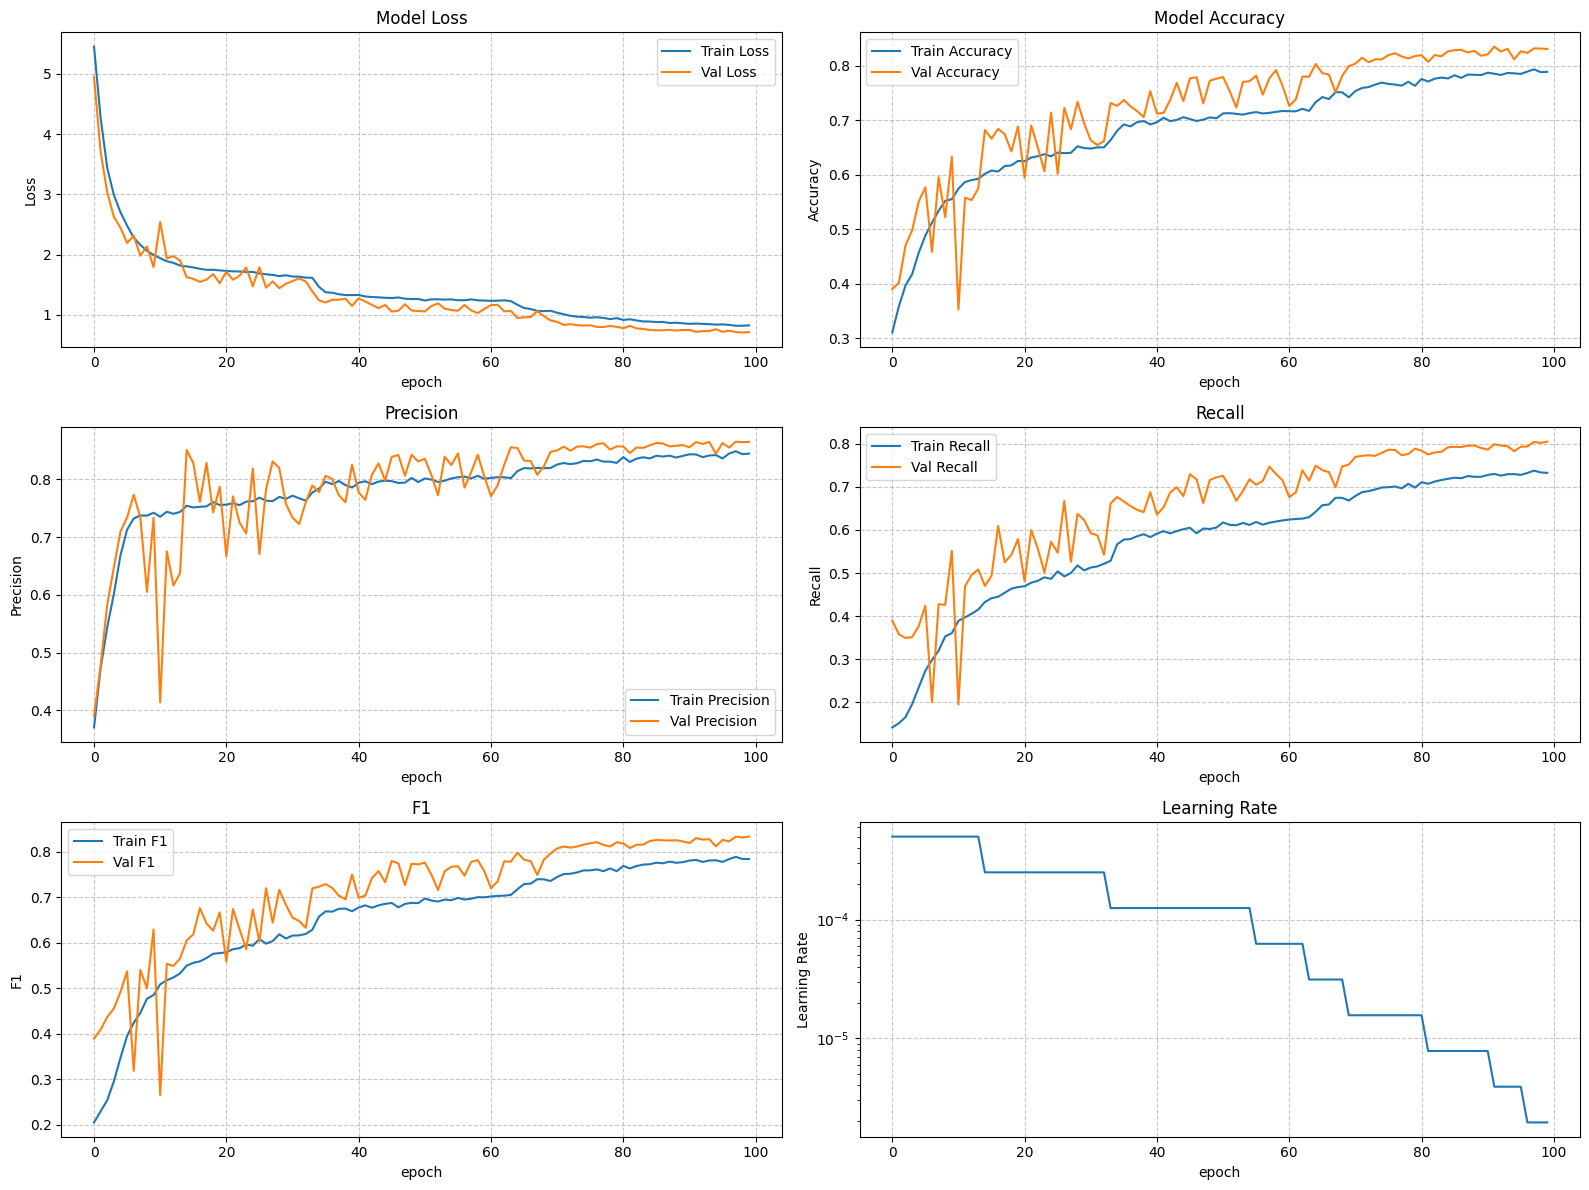

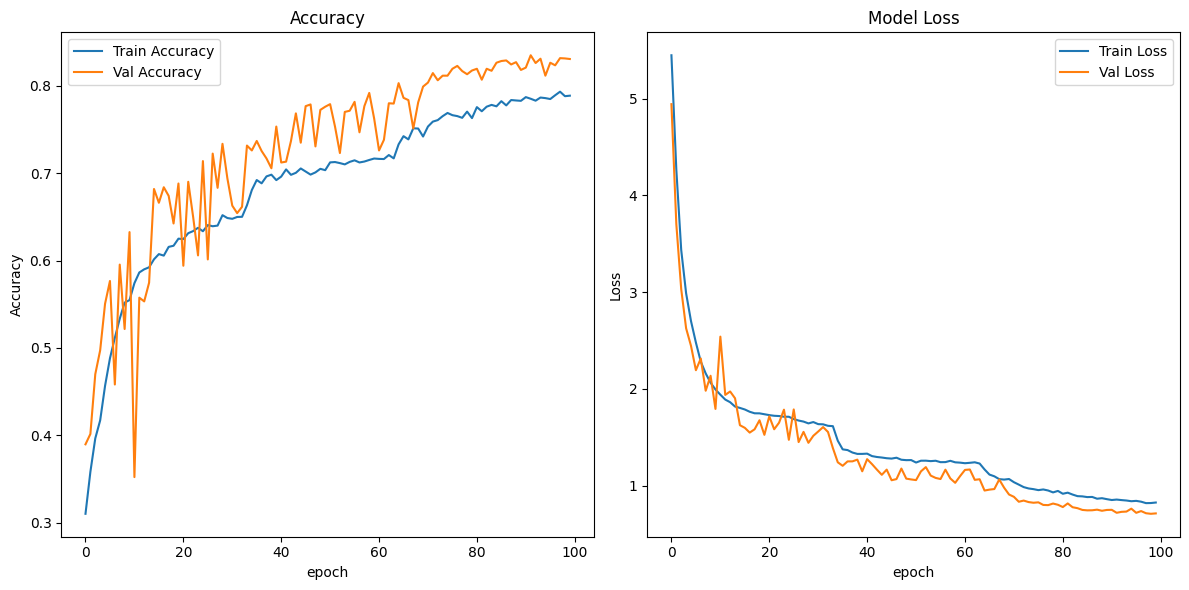

In [2]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 96, 96  # 增大尺寸以获取更多人脸细节

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32   # 减小batch_size以提高人脸预处理器性能
epochs = 100       # 减少训练轮数以快速验证

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 先创建基本的数据生成器对象
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            rescale=1./255
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='grayscale',
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='grayscale',
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到标准数据生成器。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 构建优化的CNN模型，适应处理后的人脸图像
model = Sequential([
    # 输入层 - 调整为适应更大的人脸图像尺寸
    Input(shape=(img_width, img_height, 1)),
    
    # 第一层卷积 - 特征提取
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # 第二层卷积
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # 第三层卷积
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # 第四层卷积 - 增加一层特征提取
    Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # 第五层卷积 - 更深层次的特征提取
    Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.25),
    
    # 展平层
    Flatten(),
    
    # 全连接层 - 特征处理
    Dense(1024, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    
    # 中间层 - 减少过拟合
    Dense(512, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    
    # 附加中间层 - 增强特征表达能力
    Dense(256, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    
    # 输出层
    Dense(len(class_labels), activation='softmax')
])

# 编译模型
# 针对更大模型调整学习率和优化器参数
initial_learning_rate = 0.0005  # 降低学习率以适应更大的模型
optimizer = Adam(
    learning_rate=initial_learning_rate,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False
)

# 使用兼容的指标格式
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy', 
        Precision(name='precision'), 
        Recall(name='recall')
    ]  # 使用具体的指标对象
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # 监控验证准确率而不是损失
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改进的CNN架构，包含更多卷积层和特征提取能力")
print("   - 使用LeakyReLU激活函数和L2正则化减少过拟合")
print("   - 增强的数据增强策略提高模型泛化能力")
print("   - 自适应学习率调整和早停机制优化训练过程")
print("   - 多指标评估（准确率、精确率、召回率、F1分数）")
print("4. 可调整参数:")
print("   - 'initial_learning_rate': 初始学习率")
print("   - 'batch_size': 批次大小")
print("   - 'epochs': 训练轮数")
print("   - 数据增强参数在'train_datagen'中设置")
print("5. 如有任何问题，请先运行 fix_deps.bat 来修复依赖项")
print("6. 建议在训练后查看完整的评估结果和训练历史图表")
print("7. 人脸预处理功能：")
print("   - 模型现在集成了MTCNN人脸检测和对齐功能")
print("   - 首次运行时会下载MTCNN权重文件，这可能需要一些时间")
print("   - 如果人脸检测失败，会自动切换到标准数据处理流程")
print("   - 人脸预处理模块位于face_preprocessor.py中，可以单独使用")
print("8. 可调整的人脸预处理参数：")
print("   - 在face_preprocessor.py中可以调整padding（人脸框填充像素）")
print("   - 可以修改confidence_threshold（人脸检测置信度阈值）")
print("   - 数据增强参数在create_face_preprocessing_generator调用中设置")
print("9. 模型尺寸调整：")
print("   - 输入图像尺寸已从48x48调整为96x96，以获取更多人脸细节")
print("   - CNN模型结构已优化，增加了卷积层和全连接层以适应更大的输入尺寸")
print("   - 学习率已降低以适应更大的模型结构")


2025-10-09 01:58:57.098064: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-09 01:58:57.301051: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-09 01:59:00.913235: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-09 01:59:01.665799: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到标准数据生成器。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']


2025-10-09 01:59:09.738919: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-09 01:59:12.447573: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:42] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-10-09 01:59:12.447626: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3956 MB memory:  -> device: 0, name: B1.gpu.small, pci bus id: 0000:14:00.0, compute capability: 8.6


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 96, 96, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 96, 96, 32)       128       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 96, 96, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 48, 48, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 48, 48, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        1

2025-10-09 01:59:19.547021: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-10-09 01:59:27.043435: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


383/383 [==============================] - ETA: 0s - loss: 5.4100 - accuracy: 0.3133 - precision: 0.3812 - recall: 0.1387
Epoch 1: val_accuracy improved from -inf to 0.38980, saving model to models/fer2013_best_model.h5

Epoch 1/200
训练: 损失=5.4100, 准确率=0.3133
训练: 精确率=0.3812, 召回率=0.1387
验证: 损失=4.8961, 准确率=0.3898
验证: 精确率=0.3898, 召回率=0.3898
验证: F1分数=0.3898
已用时: 0.79分钟, 预计剩余: 157.19分钟
当前学习率: 0.000500
383/383 [==============================] - 47s 86ms/step - loss: 5.4100 - accuracy: 0.3133 - precision: 0.3812 - recall: 0.1387 - val_loss: 4.8961 - val_accuracy: 0.3898 - val_precision: 0.3898 - val_recall: 0.3898 - lr: 5.0000e-04
Epoch 2/200
383/383 [==============================] - ETA: 0s - loss: 4.2147 - accuracy: 0.3722 - precision: 0.4876 - recall: 0.1563
Epoch 2: val_accuracy improved from 0.38980 to 0.44375, saving model to models/fer2013_best_model.h5

Epoch 2/200
训练: 损失=4.2147, 准确率=0.3722
训练: 精确率=0.4876, 召回率=0.1563
验证: 损失=3.6179, 准确率=0.4437
验证: 精确率=0.5804, 召回率=0.2862
验证: F1分数=0.3833

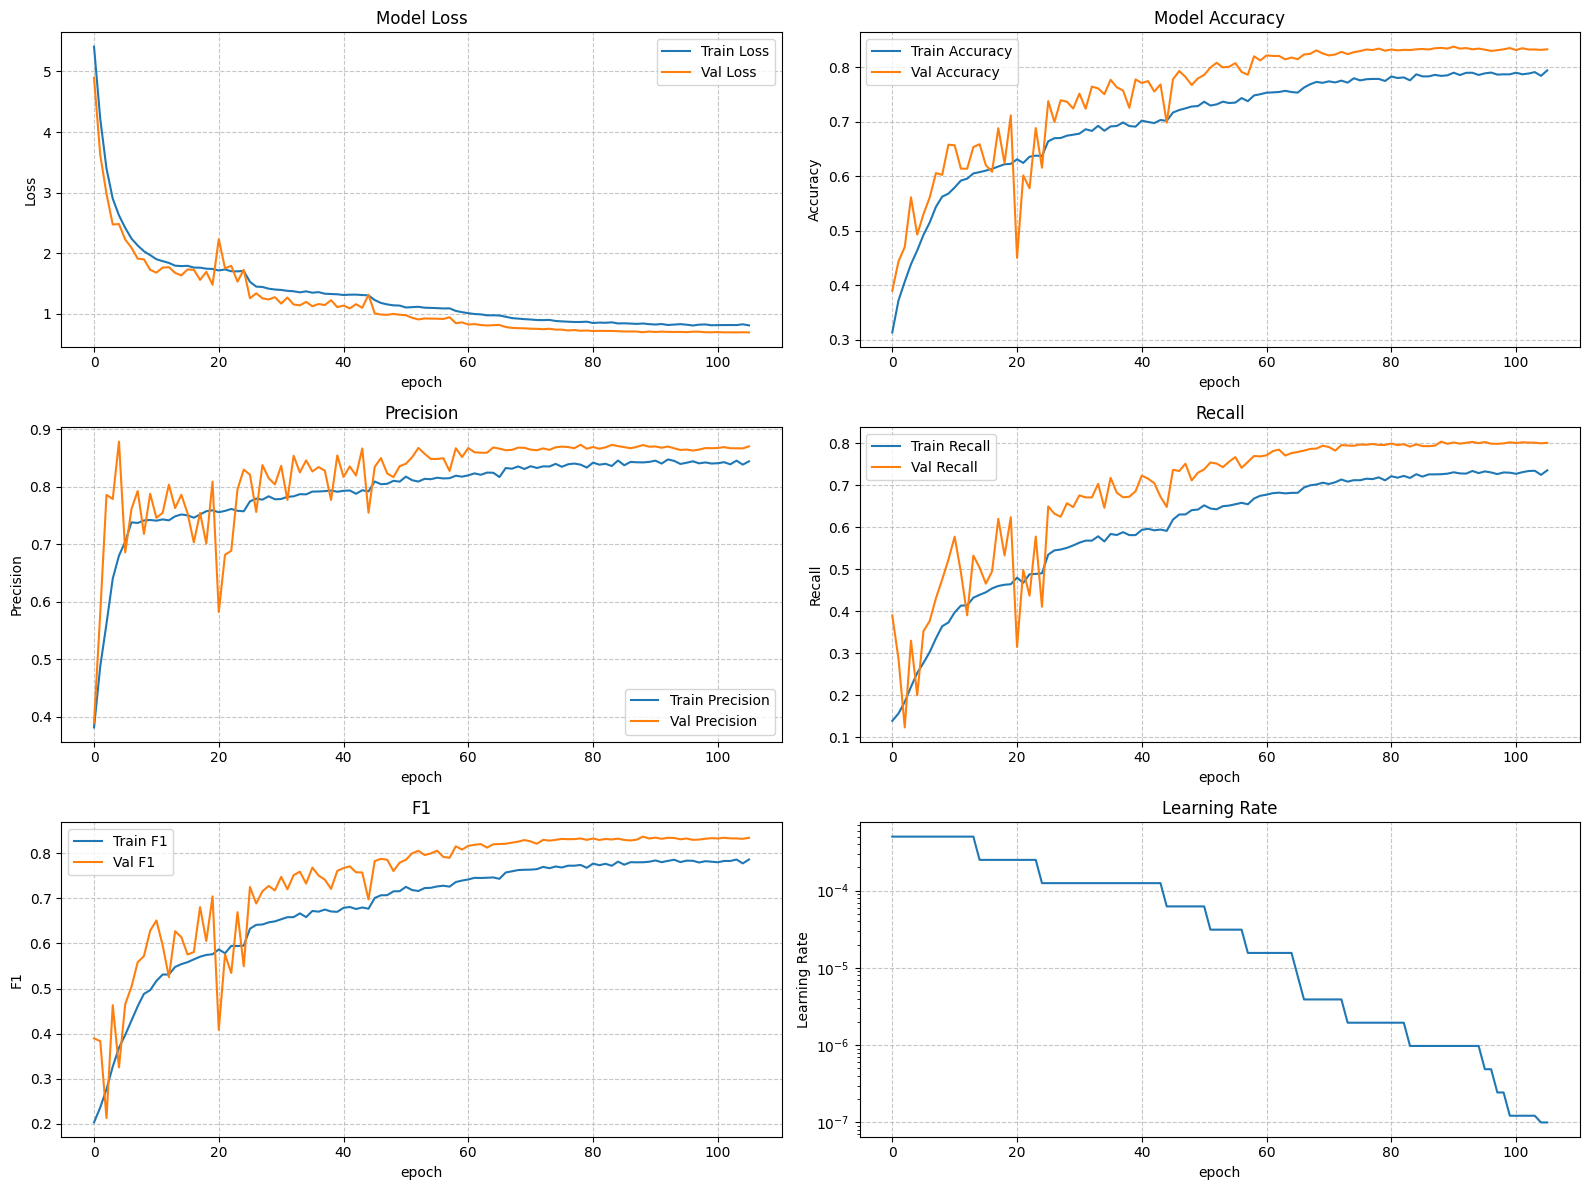

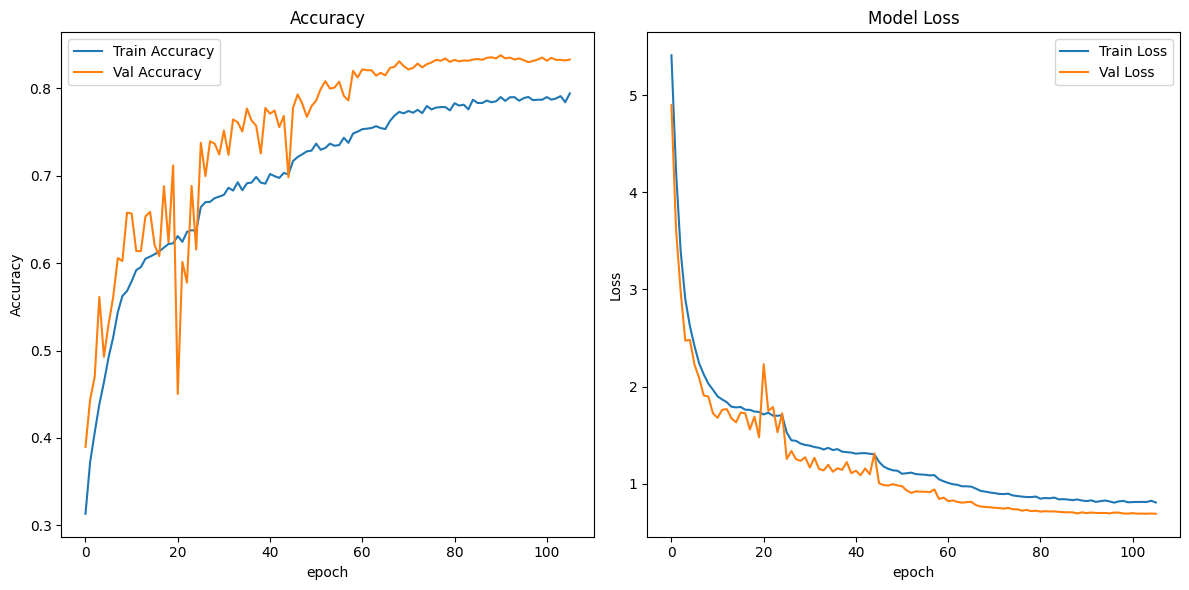

In [1]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 96, 96  # 增大尺寸以获取更多人脸细节

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32   # 减小batch_size以提高人脸预处理器性能
epochs = 200       # 减少训练轮数以快速验证

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 先创建基本的数据生成器对象
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            rescale=1./255
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='grayscale',
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='grayscale',
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到标准数据生成器。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 构建优化的CNN模型，适应处理后的人脸图像
model = Sequential([
    # 输入层 - 调整为适应更大的人脸图像尺寸
    Input(shape=(img_width, img_height, 1)),
    
    # 第一层卷积 - 特征提取
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # 第二层卷积
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # 第三层卷积
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # 第四层卷积 - 增加一层特征提取
    Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # 第五层卷积 - 更深层次的特征提取
    Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.25),
    
    # 展平层
    Flatten(),
    
    # 全连接层 - 特征处理
    Dense(1024, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    
    # 中间层 - 减少过拟合
    Dense(512, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    
    # 附加中间层 - 增强特征表达能力
    Dense(256, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    
    # 输出层
    Dense(len(class_labels), activation='softmax')
])

# 编译模型
# 针对更大模型调整学习率和优化器参数
initial_learning_rate = 0.0005  # 降低学习率以适应更大的模型
optimizer = Adam(
    learning_rate=initial_learning_rate,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False
)

# 使用兼容的指标格式
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy', 
        Precision(name='precision'), 
        Recall(name='recall')
    ]  # 使用具体的指标对象
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # 监控验证准确率而不是损失
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改进的CNN架构，包含更多卷积层和特征提取能力")
print("   - 使用LeakyReLU激活函数和L2正则化减少过拟合")
print("   - 增强的数据增强策略提高模型泛化能力")
print("   - 自适应学习率调整和早停机制优化训练过程")
print("   - 多指标评估（准确率、精确率、召回率、F1分数）")
print("4. 可调整参数:")
print("   - 'initial_learning_rate': 初始学习率")
print("   - 'batch_size': 批次大小")
print("   - 'epochs': 训练轮数")
print("   - 数据增强参数在'train_datagen'中设置")
print("5. 如有任何问题，请先运行 fix_deps.bat 来修复依赖项")
print("6. 建议在训练后查看完整的评估结果和训练历史图表")
print("7. 人脸预处理功能：")
print("   - 模型现在集成了MTCNN人脸检测和对齐功能")
print("   - 首次运行时会下载MTCNN权重文件，这可能需要一些时间")
print("   - 如果人脸检测失败，会自动切换到标准数据处理流程")
print("   - 人脸预处理模块位于face_preprocessor.py中，可以单独使用")
print("8. 可调整的人脸预处理参数：")
print("   - 在face_preprocessor.py中可以调整padding（人脸框填充像素）")
print("   - 可以修改confidence_threshold（人脸检测置信度阈值）")
print("   - 数据增强参数在create_face_preprocessing_generator调用中设置")
print("9. 模型尺寸调整：")
print("   - 输入图像尺寸已从48x48调整为96x96，以获取更多人脸细节")
print("   - CNN模型结构已优化，增加了卷积层和全连接层以适应更大的输入尺寸")
print("   - 学习率已降低以适应更大的模型结构")


2025-10-06 14:23:22.098701: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-06 14:23:23.836820: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-06 14:23:29.527099: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-06 14:23:36.151026: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已使用标准RGB数据生成器。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别计数: [705, 717, 281, 4772, 2524, 1982, 1290]
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}


2025-10-06 14:24:01.782624: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-06 14:24:03.884283: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:42] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-10-06 14:24:03.884339: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3956 MB memory:  -> device: 0, name: B1.gpu.small, pci bus id: 0000:13:00.0, compute capability: 8.6


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 96, 96, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 96, 96, 32)       128       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 96, 96, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 48, 48, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 48, 48, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        1

2025-10-06 14:24:09.888771: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-10-06 14:24:17.251596: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


...

findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
/tmp/ipykernel_117/819016835.py:461: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_117/819016835.py:461: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from current font.
  plt.tight_layout()
findfont: Font family 'SimHei' not found.


完整训练历史图表已保存。


findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
/tmp/ipykernel_117/819016835.py:486: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
/tmp/ipykernel_117/819016835.py:486: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
/tmp/ipykernel_117/819016835.py:486: UserWarning: Glyph 29575 (\N{CJK 

简化训练历史图表已保存。
在无头环境中运行，跳过显示图表。

训练完成!

使用说明:
1. 训练好的模型保存在 'models/' 文件夹中:
   - 'fer2013_best_model.h5': 验证集性能最佳的模型
   - 'fer2013_final_model.h5': 最终训练轮次的模型
2. 训练相关文件:
   - 'logs/training_history.csv': 详细的训练日志
   - 'logs/evaluation_results.txt': 模型评估结果
   - 'plots/training_history_full.png': 完整的训练历史图表
   - 'plots/training_history_simple.png': 简化的训练历史图表
3. 主要优化点:
   - 改为RGB输入，使用Label Smoothing与Top-2准确率
   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合
   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参
   - 稳健的数据增强与学习率调度


findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not

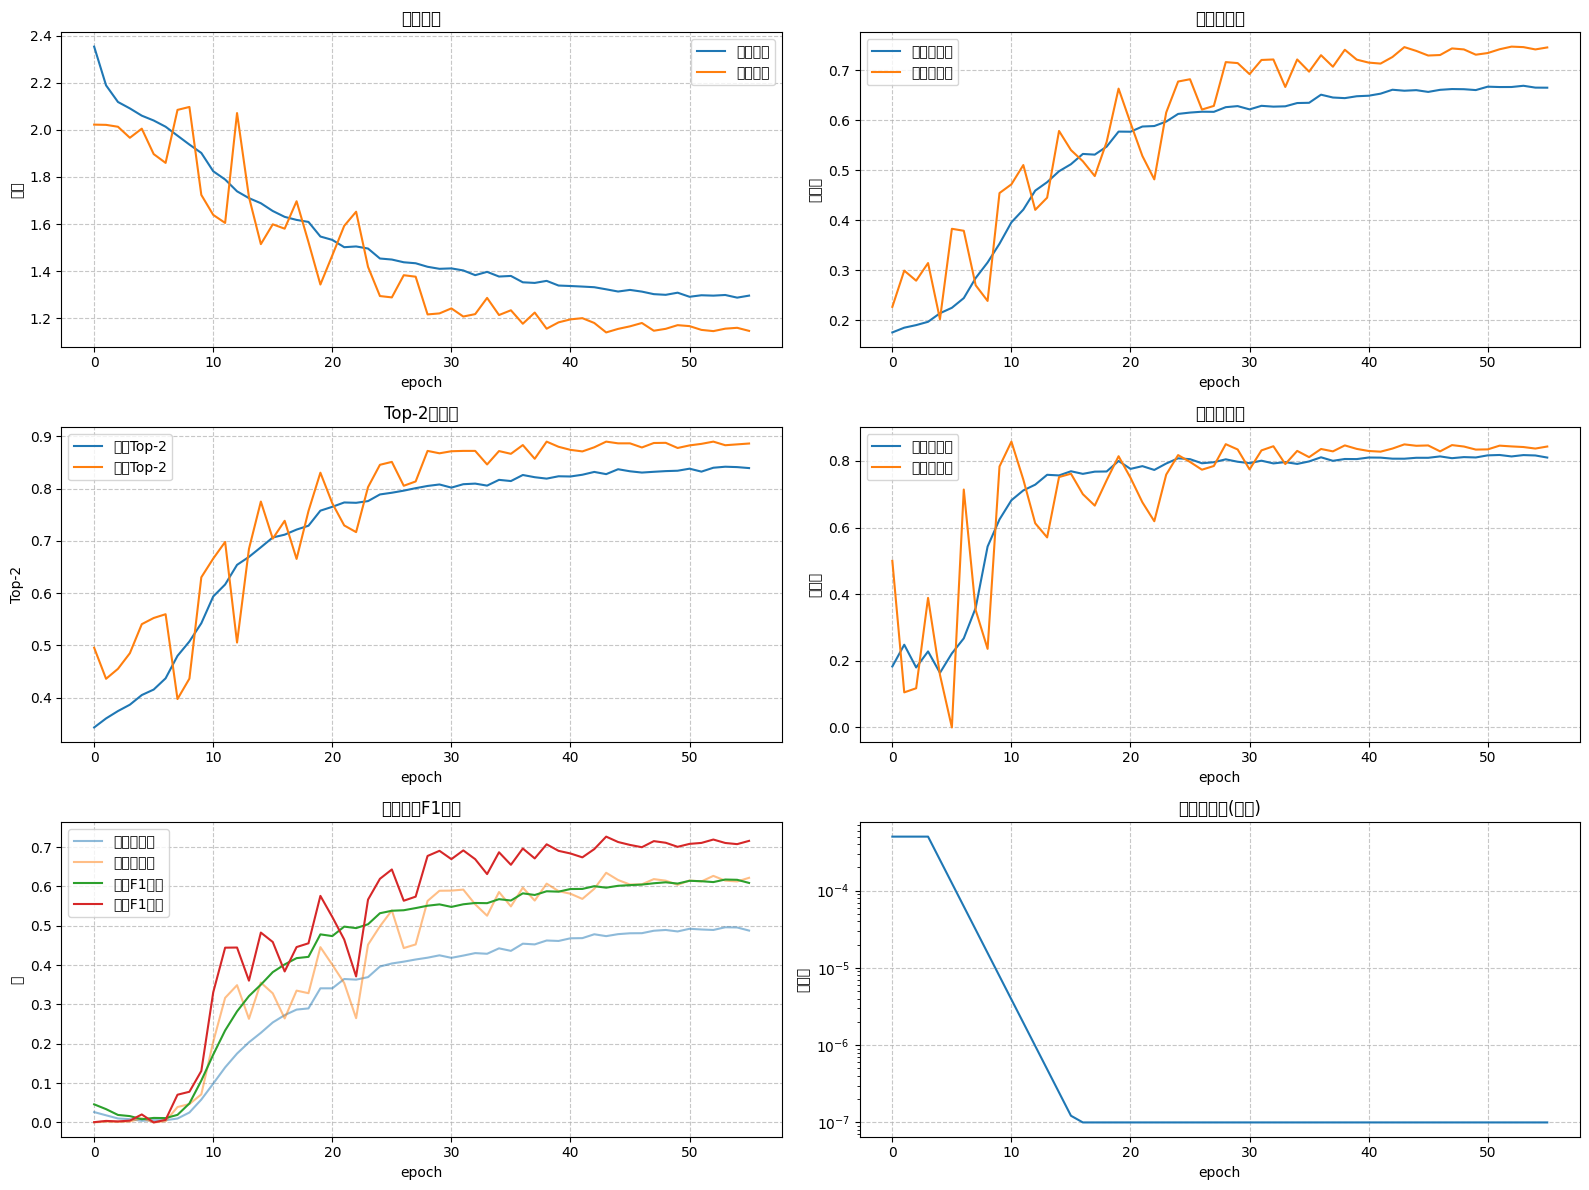

findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not

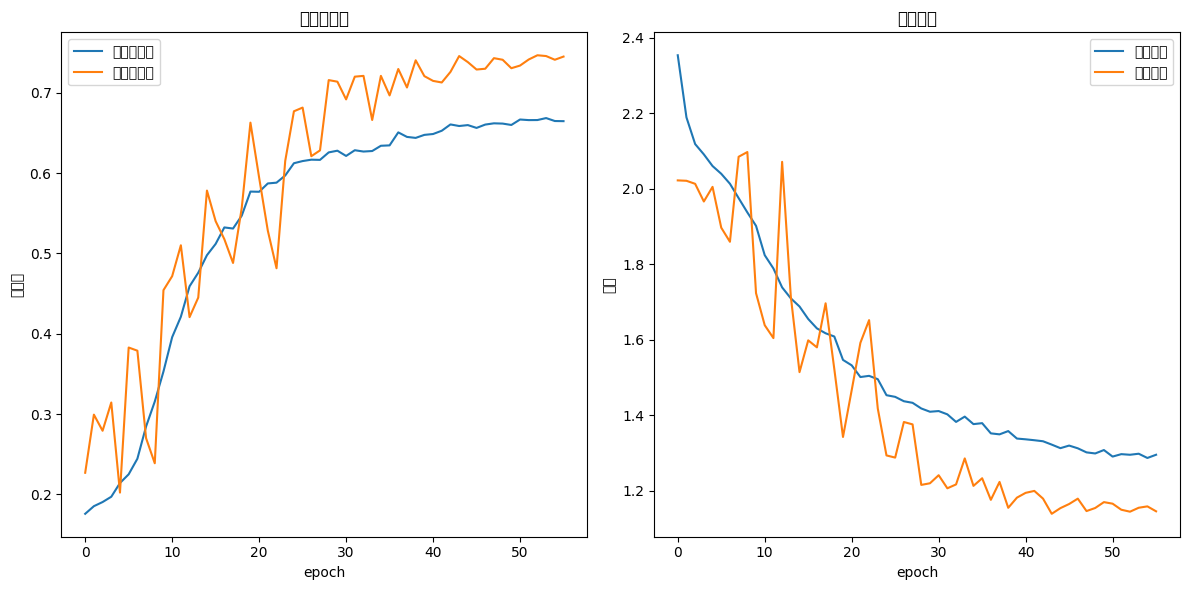

In [1]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Input, LeakyReLU, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
plt.rcParams["font.family"] = ["SimHei"]
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 96, 96  # 增大尺寸以获取更多人脸细节

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32
epochs = 100

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 数据增强（适度、稳健）
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.15,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.85, 1.15],
            channel_shift_range=0.05
        )
        
        validation_datagen = ImageDataGenerator(
            rescale=1./255
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已使用标准RGB数据生成器。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（应对类别不均衡）
classes_arr = train_generator.classes
class_counts = np.bincount(classes_arr)
num_classes = len(class_counts)
total_samples = classes_arr.shape[0]
class_weights = {i: total_samples / (num_classes * class_counts[i]) for i in range(num_classes)}
print("类别计数:", class_counts.tolist())
print("类别权重:", class_weights)

# 构建优化的CNN模型（使用GAP替代Flatten，降低过拟合）
l2_reg = 1e-4

model = Sequential([
    Input(shape=(img_width, img_height, 3)),   # 改为3通道

    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(512, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(256, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.4),

    Dense(len(class_labels), activation='softmax')
])

# 编译模型：使用Label Smoothing与Top-2准确率
initial_learning_rate = 5e-4
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        TopKCategoricalAccuracy(k=2, name='top2_acc'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数（监控val_loss更稳定）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型（按val_loss）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs.get('accuracy', 0):.4f}, Top-2={logs.get('top2_acc', 0):.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs.get('val_accuracy', 0):.4f}, Top-2={logs.get('val_top2_acc', 0):.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        class_weight=class_weights,           # 应用类别权重
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall, 'TopKCategoricalAccuracy': TopKCategoricalAccuracy}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='训练损失')
    plt.plot(history.history['val_loss'], label='验证损失')
    plt.title('模型损失')
    plt.xlabel('epoch')
    plt.ylabel('损失')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='训练准确率')
    plt.plot(history.history['val_accuracy'], label='验证准确率')
    plt.title('模型准确率')
    plt.xlabel('epoch')
    plt.ylabel('准确率')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2.1 绘制Top-2准确率
    if 'top2_acc' in history.history and 'val_top2_acc' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['top2_acc'], label='训练Top-2')
        plt.plot(history.history['val_top2_acc'], label='验证Top-2')
        plt.title('Top-2准确率')
        plt.xlabel('epoch')
        plt.ylabel('Top-2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['precision'], label='训练精确率')
        plt.plot(history.history['val_precision'], label='验证精确率')
        plt.title('模型精确率')
        plt.xlabel('epoch')
        plt.ylabel('精确率')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                                 history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)

        plt.subplot(3, 2, 5)
        plt.plot(history.history['recall'], label='训练召回率', alpha=0.5)
        plt.plot(history.history['val_recall'], label='验证召回率', alpha=0.5)
        plt.plot(train_f1_scores, label='训练F1分数')
        plt.plot(val_f1_scores, label='验证F1分数')
        plt.title('召回率与F1分数')
        plt.xlabel('epoch')
        plt.ylabel('值')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化（基于val_loss的简易模拟）
    plt.subplot(3, 2, 6)
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    if 'val_loss' in history.history:
        for i in range(1, len(history.history['loss'])):
            if i >= reduce_lr.patience:
                prev_best = min(history.history['val_loss'][:i])
                window_best = min(history.history['val_loss'][i-reduce_lr.patience:i])
                # 若窗口内最优没有优于之前最优，则降LR（近似模拟）
                if window_best >= prev_best - 1e-12:
                    current_lr = max(current_lr * reduce_lr.factor, reduce_lr.min_lr)
            lr_history.append(current_lr)
    else:
        lr_history = [initial_learning_rate] * len(history.history['loss'])
    
    plt.plot(lr_history)
    plt.title('学习率变化(近似)')
    plt.xlabel('epoch')
    plt.ylabel('学习率')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='训练准确率')
    plt.plot(history.history['val_accuracy'], label='验证准确率')
    plt.title('模型准确率')
    plt.xlabel('epoch')
    plt.ylabel('准确率')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='训练损失')
    plt.plot(history.history['val_loss'], label='验证损失')
    plt.title('模型损失')
    plt.xlabel('epoch')
    plt.ylabel('损失')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改为RGB输入，使用Label Smoothing与Top-2准确率")
print("   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合")
print("   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参")
print("   - 稳健的数据增强与学习率调度")


In [3]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Input, LeakyReLU, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy
import matplotlib.pyplot as plt
# 设置matplotlib字体支持
plt.rcParams["font.family"] = ["DejaVu Sans"]
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = True

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 96, 96  # 增大尺寸以获取更多人脸细节

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32
epochs = 100

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 数据增强（适度、稳健）
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.15,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.85, 1.15],
            channel_shift_range=0.05
        )
        
        validation_datagen = ImageDataGenerator(
            rescale=1./255
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已使用标准RGB数据生成器。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（应对类别不均衡）
classes_arr = train_generator.classes
class_counts = np.bincount(classes_arr)
num_classes = len(class_counts)
total_samples = classes_arr.shape[0]
class_weights = {i: total_samples / (num_classes * class_counts[i]) for i in range(num_classes)}
print("类别计数:", class_counts.tolist())
print("类别权重:", class_weights)

# 构建优化的CNN模型（使用GAP替代Flatten，降低过拟合）
l2_reg = 1e-4

model = Sequential([
    Input(shape=(img_width, img_height, 3)),   # 改为3通道

    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(512, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(256, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.4),

    Dense(len(class_labels), activation='softmax')
])

# 编译模型：使用Label Smoothing与Top-2准确率
initial_learning_rate = 5e-4
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        TopKCategoricalAccuracy(k=2, name='top2_acc'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数（监控val_loss更稳定）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型（按val_loss）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs.get('accuracy', 0):.4f}, Top-2={logs.get('top2_acc', 0):.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs.get('val_accuracy', 0):.4f}, Top-2={logs.get('val_top2_acc', 0):.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        class_weight=class_weights,           # 应用类别权重
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall, 'TopKCategoricalAccuracy': TopKCategoricalAccuracy}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2.1 绘制Top-2准确率
    if 'top2_acc' in history.history and 'val_top2_acc' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['top2_acc'], label='Train Top-2')
        plt.plot(history.history['val_top2_acc'], label='Val Top-2')
        plt.title('Top-2 Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Top-2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Model Precision')
        plt.xlabel('Epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                                 history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)

        plt.subplot(3, 2, 5)
        plt.plot(history.history['recall'], label='Train Recall', alpha=0.5)
        plt.plot(history.history['val_recall'], label='Val Recall', alpha=0.5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('Recall and F1 Score')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化（基于val_loss的简易模拟）
    plt.subplot(3, 2, 6)
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    if 'val_loss' in history.history:
        for i in range(1, len(history.history['loss'])):
            if i >= reduce_lr.patience:
                prev_best = min(history.history['val_loss'][:i])
                window_best = min(history.history['val_loss'][i-reduce_lr.patience:i])
                # 若窗口内最优没有优于之前最优，则降LR（近似模拟）
                if window_best >= prev_best - 1e-12:
                    current_lr = max(current_lr * reduce_lr.factor, reduce_lr.min_lr)
            lr_history.append(current_lr)
    else:
        lr_history = [initial_learning_rate] * len(history.history['loss'])
    
    plt.plot(lr_history)
    plt.title('Learning Rate (approx)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改为RGB输入，使用Label Smoothing与Top-2准确率")
print("   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合")
print("   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参")
print("   - 稳健的数据增强与学习率调度")


启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已使用标准RGB数据生成器。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别计数: [705, 717, 281, 4772, 2524, 1982, 1290]
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 96, 96, 32)        896       
                                                                 
 batch_normalization_8 (Batc  (None, 96, 96, 32)       128       
 hNormalization)                                                 
                                         

KeyboardInterrupt: 

2025-10-07 05:56:37.668158: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 05:56:41.193185: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 05:56:47.061708: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 05:56:50.544294: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已使用标准RGB数据生成器。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别计数: [705, 717, 281, 4772, 2524, 1982, 1290]
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}


2025-10-07 05:57:03.773842: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 05:57:06.056958: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:42] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-10-07 05:57:06.057004: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17982 MB memory:  -> device: 0, name: P1.gpu.small, pci bus id: 0000:35:00.0, compute capability: 8.0


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 96, 96, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 96, 96, 32)       128       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 96, 96, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 48, 48, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 48, 48, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        1

2025-10-07 05:57:13.179290: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-10-07 05:57:19.838683: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


...

/tmp/ipykernel_108/2050455358.py:462: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:462: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:462: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:462: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:462: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:462: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:462: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from current font.
  plt.tight_l

完整训练历史图表已保存。


/tmp/ipykernel_108/2050455358.py:486: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:486: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:486: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:486: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:486: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:486: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108/2050455358.py:486: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_l

简化训练历史图表已保存。
在无头环境中运行，跳过显示图表。

训练完成!

使用说明:
1. 训练好的模型保存在 'models/' 文件夹中:
   - 'fer2013_best_model.h5': 验证集性能最佳的模型
   - 'fer2013_final_model.h5': 最终训练轮次的模型
2. 训练相关文件:
   - 'logs/training_history.csv': 详细的训练日志
   - 'logs/evaluation_results.txt': 模型评估结果
   - 'plots/training_history_full.png': 完整的训练历史图表
   - 'plots/training_history_simple.png': 简化的训练历史图表
3. 主要优化点:
   - 改为RGB输入，使用Label Smoothing与Top-2准确率
   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合
   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参
   - 稳健的数据增强与学习率调度


/root/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  fig.canvas.print_fig

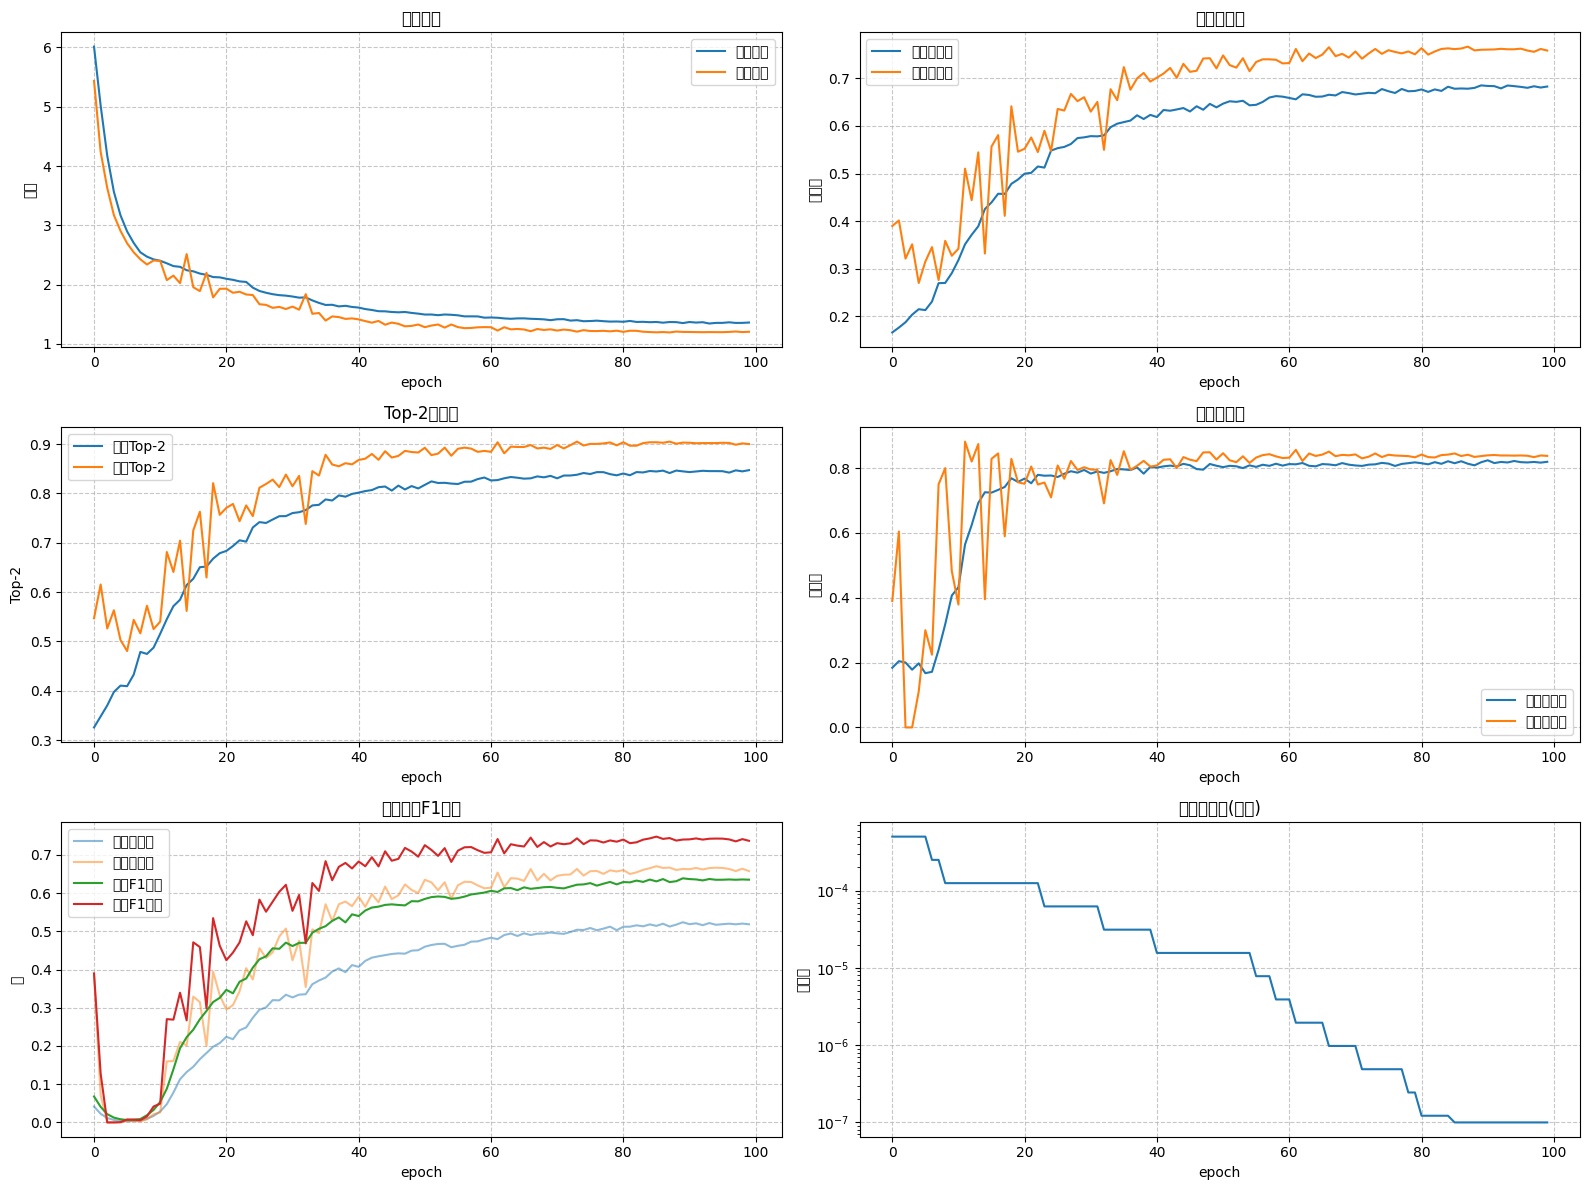

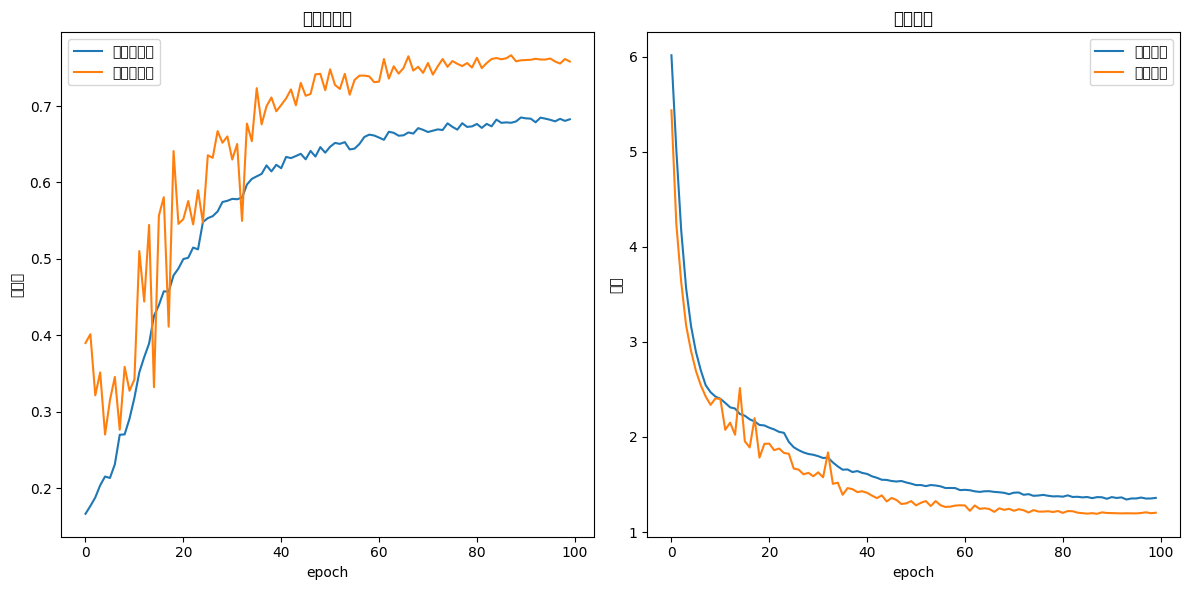

In [1]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Input, LeakyReLU, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy
import matplotlib.pyplot as plt
# 设置matplotlib字体支持
plt.rcParams["font.family"] = ["DejaVu Sans"]
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = True

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 96, 96  # 增大尺寸以获取更多人脸细节

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32
epochs = 100

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 数据增强（适度、稳健）
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            rescale=1./255
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已使用标准RGB数据生成器。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（应对类别不均衡）
classes_arr = train_generator.classes
class_counts = np.bincount(classes_arr)
num_classes = len(class_counts)
total_samples = classes_arr.shape[0]
class_weights = {i: total_samples / (num_classes * class_counts[i]) for i in range(num_classes)}
print("类别计数:", class_counts.tolist())
print("类别权重:", class_weights)

# 构建优化的CNN模型（使用GAP替代Flatten，降低过拟合）
l2_reg = 0.001

model = Sequential([
    Input(shape=(img_width, img_height, 3)),   # 仍保持RGB三通道

    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.25),

    # 改为 Flatten + 全连接层结构（与上面代码一致风格）
    Flatten(),

    Dense(1024, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(512, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(256, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(len(class_labels), activation='softmax')
])

# 编译模型：使用Label Smoothing与Top-2准确率
initial_learning_rate = 5e-4
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        TopKCategoricalAccuracy(k=2, name='top2_acc'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数（监控val_accuracy）
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型（按val_loss）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs.get('accuracy', 0):.4f}, Top-2={logs.get('top2_acc', 0):.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs.get('val_accuracy', 0):.4f}, Top-2={logs.get('val_top2_acc', 0):.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        class_weight=class_weights,           # 应用类别权重
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall, 'TopKCategoricalAccuracy': TopKCategoricalAccuracy}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='训练损失')
    plt.plot(history.history['val_loss'], label='验证损失')
    plt.title('模型损失')
    plt.xlabel('epoch')
    plt.ylabel('损失')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='训练准确率')
    plt.plot(history.history['val_accuracy'], label='验证准确率')
    plt.title('模型准确率')
    plt.xlabel('epoch')
    plt.ylabel('准确率')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2.1 绘制Top-2准确率
    if 'top2_acc' in history.history and 'val_top2_acc' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['top2_acc'], label='训练Top-2')
        plt.plot(history.history['val_top2_acc'], label='验证Top-2')
        plt.title('Top-2准确率')
        plt.xlabel('epoch')
        plt.ylabel('Top-2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['precision'], label='训练精确率')
        plt.plot(history.history['val_precision'], label='验证精确率')
        plt.title('模型精确率')
        plt.xlabel('epoch')
        plt.ylabel('精确率')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                                 history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)

        plt.subplot(3, 2, 5)
        plt.plot(history.history['recall'], label='训练召回率', alpha=0.5)
        plt.plot(history.history['val_recall'], label='验证召回率', alpha=0.5)
        plt.plot(train_f1_scores, label='训练F1分数')
        plt.plot(val_f1_scores, label='验证F1分数')
        plt.title('召回率与F1分数')
        plt.xlabel('epoch')
        plt.ylabel('值')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化（按val_accuracy的近似模拟）
    plt.subplot(3, 2, 6)
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        if i >= reduce_lr.patience and 'val_accuracy' in history.history:
            recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
            if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                current_lr = max(current_lr * reduce_lr.factor, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('学习率变化(近似)')
    plt.xlabel('epoch')
    plt.ylabel('学习率')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='训练准确率')
    plt.plot(history.history['val_accuracy'], label='验证准确率')
    plt.title('模型准确率')
    plt.xlabel('epoch')
    plt.ylabel('准确率')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='训练损失')
    plt.plot(history.history['val_loss'], label='验证损失')
    plt.title('模型损失')
    plt.xlabel('epoch')
    plt.ylabel('损失')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改为RGB输入，使用Label Smoothing与Top-2准确率")
print("   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合")
print("   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参")
print("   - 稳健的数据增强与学习率调度")


In [ ]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Input, LeakyReLU, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy
import matplotlib.pyplot as plt
# 设置matplotlib字体支持
plt.rcParams["font.family"] = ["DejaVu Sans"]
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = True

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 96, 96  # 增大尺寸以获取更多人脸细节

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32
epochs = 100

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 数据增强（适度、稳健）
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            rescale=1./255
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已使用标准RGB数据生成器。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（应对类别不均衡）
classes_arr = train_generator.classes
class_counts = np.bincount(classes_arr)
num_classes = len(class_counts)
total_samples = classes_arr.shape[0]
class_weights = {i: total_samples / (num_classes * class_counts[i]) for i in range(num_classes)}
print("类别计数:", class_counts.tolist())
print("类别权重:", class_weights)

# 构建优化的CNN模型（使用GAP替代Flatten，降低过拟合）
l2_reg = 0.001

model = Sequential([
    Input(shape=(img_width, img_height, 3)),   # 仍保持RGB三通道

    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.25),

    # 改为 Flatten + 全连接层结构（与上面代码一致风格）
    Flatten(),

    Dense(1024, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(512, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(256, kernel_regularizer=l2(l2_reg)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(len(class_labels), activation='softmax')
])

# 编译模型：使用Label Smoothing与Top-2准确率
initial_learning_rate = 5e-4
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        TopKCategoricalAccuracy(k=2, name='top2_acc'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数（监控val_accuracy）
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型（按val_loss）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs.get('accuracy', 0):.4f}, Top-2={logs.get('top2_acc', 0):.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs.get('val_accuracy', 0):.4f}, Top-2={logs.get('val_top2_acc', 0):.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        class_weight=class_weights,           # 应用类别权重
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall, 'TopKCategoricalAccuracy': TopKCategoricalAccuracy}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. Loss
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Accuracy
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2.1 Top-2 Accuracy
    if 'top2_acc' in history.history and 'val_top2_acc' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['top2_acc'], label='Train Top-2')
        plt.plot(history.history['val_top2_acc'], label='Val Top-2')
        plt.title('Top-2 Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Top-2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. Precision
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Model Precision')
        plt.xlabel('Epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        # F1
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                                 history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)

        plt.subplot(3, 2, 5)
        plt.plot(history.history['recall'], label='Train Recall', alpha=0.5)
        plt.plot(history.history['val_recall'], label='Val Recall', alpha=0.5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('Recall and F1 Score')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. Learning rate (approx)
    plt.subplot(3, 2, 6)
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        if i >= reduce_lr.patience and 'val_accuracy' in history.history:
            recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
            if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                current_lr = max(current_lr * reduce_lr.factor, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate (approx)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存单独的简化图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 简化图表
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改为RGB输入，使用Label Smoothing与Top-2准确率")
print("   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合")
print("   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参")
print("   - 稳健的数据增强与学习率调度")


In [ ]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy

# 新增：预训练骨干与预处理
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

# 可选：宏平均F1（训练期）与评估报告
try:
    import tensorflow_addons as tfa
    HAS_TFA = True
except Exception:
    HAS_TFA = False

try:
    from sklearn.metrics import classification_report, f1_score
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False

# 可选：人脸检测/对齐（MTCNN）
try:
    from mtcnn import MTCNN
    import cv2
    HAS_MTCNN = True
    _mtcnn = MTCNN()
except Exception:
    HAS_MTCNN = False

# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 训练配置
BACKBONE = 'efficientnetb0'  # 可选: 'efficientnetb0' | 'resnet50v2'
USE_ALIGNMENT = True          # 若未安装MTCNN或失败，会自动降级为False
IMG_SIZE = 224                # 迁移学习常用输入尺寸

# 图像尺寸改为224以配合预训练模型
processed_img_width, processed_img_height = IMG_SIZE, IMG_SIZE
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32
epochs = 100
WARMUP_EPOCHS = 10  # 先训分类头的轮数

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,
    'padding': 10,
    'grayscale': True
}

# 已移除旧的 rescale=1./255 的 ImageDataGenerator 数据管线。
# 统一在下方 use_alignment_runtime 分支中构建数据集（MTCNN对齐或预处理版ImageDataGenerator）。

# 根据所选骨干设置预处理
if BACKBONE.lower() == 'resnet50v2':
    preprocess_input = resnet_preprocess
else:
    preprocess_input = eff_preprocess

# 可选：人脸对齐的python函数（用于tf.py_function），若失败则回退原图
def _detect_align_bgr(bgr, target_size=(IMG_SIZE, IMG_SIZE), padding=10):
    try:
        if not HAS_MTCNN:
            raise RuntimeError("MTCNN not available")
        h, w = bgr.shape[:2]
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        res = _mtcnn.detect_faces(rgb)
        if not res:
            raise RuntimeError("no face")
        x, y, w0, h0 = res[0]['box']
        x1 = max(0, x - padding); y1 = max(0, y - padding)
        x2 = min(w, x + w0 + padding); y2 = min(h, y + h0 + padding)
        crop = rgb[y1:y2, x1:x2]
        if crop.size == 0:
            crop = rgb
        out = cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)
        return out
    except Exception:
        # 回退：保持原图并resize
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)

# 若使用对齐，构建tf.data数据管线；否则沿用ImageDataGenerator
def build_aligned_dataset(data_dir, batch_size, is_training):
    # 扫描文件与标签
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    file_paths, labels = [], []
    for c in class_names:
        cdir = os.path.join(data_dir, c)
        for root, _, files in os.walk(cdir):
            for fn in files:
                if fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    file_paths.append(os.path.join(root, fn))
                    labels.append(class_to_idx[c])
    file_paths = np.array(file_paths); labels = np.array(labels, dtype=np.int32)

    def _load_align(path, label):
        path = path.numpy().decode('utf-8')
        bgr = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)  # 兼容中文路径
        if bgr is None:
            # 读取失败返回黑图
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = _detect_align_bgr(bgr, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32)
        img = preprocess_input(img)  # 预训练模型预处理
        onehot = tf.keras.utils.to_categorical(label, num_classes=len(class_names))
        return img, onehot

    def _tf_wrapper(path, label):
        img, onehot = tf.py_function(func=_load_align, inp=[path, label], Tout=[tf.float32, tf.float32])
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        onehot.set_shape((len(class_names),))
        return img, onehot

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if is_training:
        ds = ds.shuffle(len(file_paths), reshuffle_each_iteration=True)
    ds = ds.map(_tf_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    if is_training:
        # 轻量色彩增强（在预处理前做更合适，此处已是预处理后，保持简单直接使用）
        pass
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    steps = len(file_paths) // batch_size
    return ds, class_names, labels, steps

# 数据加载：优先使用对齐管线
use_alignment_runtime = USE_ALIGNMENT and HAS_MTCNN
if use_alignment_runtime:
    print("使用MTCNN人脸检测/对齐 + tf.data 管线")
    train_ds, class_labels, train_labels_np, steps_per_epoch = build_aligned_dataset(train_dir, batch_size, True)
    val_ds, _, val_labels_np, val_steps = build_aligned_dataset(val_dir, batch_size, False)
    num_classes = len(class_labels)
    class_counts = np.bincount(train_labels_np, minlength=num_classes)
    total_samples = train_labels_np.shape[0]
    class_weights = {i: total_samples / (num_classes * max(class_counts[i], 1)) for i in range(num_classes)}
else:
    print("未启用对齐（缺少MTCNN或关闭），使用ImageDataGenerator")
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.15, horizontal_flip=True, brightness_range=[0.85, 1.15]
    )
    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_generator = train_datagen.flow_from_directory(
        train_dir, target_size=(img_width, img_height), batch_size=batch_size,
        color_mode='rgb', class_mode='categorical', shuffle=True
    )
    validation_generator = val_datagen.flow_from_directory(
        val_dir, target_size=(img_width, img_height), batch_size=batch_size,
        color_mode='rgb', class_mode='categorical', shuffle=False
    )
    class_labels = list(train_generator.class_indices.keys())
    num_classes = len(class_labels)
    classes_arr = train_generator.classes
    class_counts = np.bincount(classes_arr, minlength=num_classes)
    total_samples = classes_arr.shape[0]
    class_weights = {i: total_samples / (num_classes * max(class_counts[i], 1)) for i in range(num_classes)}

# 统一打印类别信息
print("情绪类别:", class_labels)
print("类别计数:", class_counts.tolist())
print("类别权重:", class_weights)

# 构建优化的CNN模型（使用GAP替代Flatten，降低过拟合）
l2_reg = 1e-4

def build_model(num_classes):
    if BACKBONE.lower() == 'resnet50v2':
        base = ResNet50V2(include_top=False, weights='imagenet', input_shape=(img_width, img_height, 3))
    else:
        base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(img_width, img_height, 3))
    base.trainable = False  # 先冻结

    model = tf.keras.Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(num_classes, activation='softmax', dtype='float32')  # 保持输出float32
    ])
    return model

model = build_model(num_classes)

# 编译：冻结阶段用稍高LR；指标：accuracy + top2 (+ macro_f1若可用)
initial_learning_rate = 1e-3
metrics = ['accuracy', TopKCategoricalAccuracy(k=2, name='top2_acc')]
if HAS_TFA:
    metrics.append(MacroF1(num_classes=num_classes, name='macro_f1'))

model.compile(optimizer=Adam(initial_learning_rate),
              loss=CategoricalCrossentropy(label_smoothing=0.1),
              metrics=metrics)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数（监控val_loss更稳定）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型（按val_loss）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs.get('accuracy', 0):.4f}, Top-2={logs.get('top2_acc', 0):.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs.get('val_accuracy', 0):.4f}, Top-2={logs.get('val_top2_acc', 0):.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    if use_alignment_runtime:
        print(f"训练样本数: {total_samples}")
        # val_ds 可能非整除，这里用估计步数
        print(f"类别数: {len(class_labels)}")
        callbacks = [early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()]
        history = model.fit(
            train_ds,
            epochs=epochs,
            validation_data=val_ds,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )
    else:
        print(f"训练样本数: {train_generator.samples}")
        print(f"验证样本数: {validation_generator.samples}")
        print(f"类别数: {len(class_labels)}")
        callbacks = [early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()]
        history = model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // batch_size,
            epochs=epochs,
            validation_data=validation_generator,
            validation_steps=validation_generator.samples // batch_size,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 评估：使用最佳模型并输出macro-F1与分类报告
print("\n评估最佳模型性能...")
best_model = tf.keras.models.load_model(
    os.path.join('models', 'fer2013_best_model.h5'),
    custom_objects={'TopKCategoricalAccuracy': TopKCategoricalAccuracy,
                    **({'F1Score': tfa.metrics.F1Score} if HAS_TFA else {})}
)

if use_alignment_runtime:
    eval_results = best_model.evaluate(val_ds, verbose=0)
    y_prob = best_model.predict(val_ds, verbose=0)
    y_true = val_labels_np
else:
    # 显式指定步数，避免进度条/阻塞问题
    val_steps = math.ceil(validation_generator.samples / validation_generator.batch_size)
    eval_results = best_model.evaluate(validation_generator, steps=val_steps, verbose=0)
    y_prob = best_model.predict(validation_generator, steps=val_steps, verbose=0)
    y_true = validation_generator.classes

loss = float(eval_results[0])
acc = float(eval_results[1])
print(f"验证集损失: {loss:.4f}")
print(f"验证集准确率: {acc:.4f}")

# 计算并输出宏平均F1与报告
y_pred = np.argmax(y_prob, axis=1)
if HAS_SKLEARN:
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"验证集宏平均F1: {macro_f1:.4f}")
    report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
    os.makedirs('logs', exist_ok=True)
    with open(os.path.join('logs', 'classification_report.txt'), 'w', encoding='utf-8') as f:
        f.write(report)
    print("已保存分类报告: logs/classification_report.txt")
else:
    print("未安装scikit-learn，跳过classification_report。建议: pip install scikit-learn")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. Loss curves
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Accuracy curves
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2.1 Top-2 Accuracy
    if 'top2_acc' in history.history and 'val_top2_acc' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['top2_acc'], label='Train Top-2')
        plt.plot(history.history['val_top2_acc'], label='Val Top-2')
        plt.title('Top-2 Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Top-2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. Precision curves
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('Epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 4. Recall & F1
    if 'recall' in history.history and 'val_recall' in history.history:
        # 计算F1
        train_f1_scores, val_f1_scores = [], []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                                 history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)

        plt.subplot(3, 2, 5)
        plt.plot(history.history['recall'], label='Train Recall', alpha=0.5)
        plt.plot(history.history['val_recall'], label='Val Recall', alpha=0.5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('Recall & F1 Score')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 5. Learning rate (approx)
    plt.subplot(3, 2, 6)
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    if 'val_loss' in history.history:
        for i in range(1, len(history.history['loss'])):
            if i >= reduce_lr.patience:
                prev_best = min(history.history['val_loss'][:i])
                window_best = min(history.history['val_loss'][i-reduce_lr.patience:i])
                if window_best >= prev_best - 1e-12:
                    current_lr = max(current_lr * reduce_lr.factor, reduce_lr.min_lr)
            lr_history.append(current_lr)
    else:
        lr_history = [initial_learning_rate] * len(history.history['loss'])
    
    plt.plot(lr_history)
    plt.title('Learning Rate (approx)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改为RGB输入，使用Label Smoothing与Top-2准确率")
print("   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合")
print("   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参")
print("   - 稳健的数据增强与学习率调度")

# 新增：将按类F1转成标量宏平均F1，避免日志中出现不可序列化的向量Tensor
if HAS_TFA:
    class MacroF1(tf.keras.metrics.Metric):
        def __init__(self, num_classes, name='macro_f1', **kwargs):
            super().__init__(name=name, **kwargs)
            # average=None 时返回每一类的F1向量
            self._f1_vec = tfa.metrics.F1Score(num_classes=num_classes, average=None)
        def update_state(self, y_true, y_pred, sample_weight=None):
            self._f1_vec.update_state(y_true, y_pred, sample_weight)
        def result(self):
            # 取均值 -> 标量，便于CSV/JSON序列化
            return tf.reduce_mean(self._f1_vec.result())
        def reset_states(self):
            self._f1_vec.reset_states()

import math
try:
    from tqdm import tqdm
    HAS_TQDM = True
except Exception:
    HAS_TQDM = False

# 独立确保cv2可用（即使未安装MTCNN也能读写/缩放）
try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

# 离线对齐缓存配置
USE_OFFLINE_ALIGNMENT = True  # 开启后会预处理一次再训练
ALIGNED_ROOT = os.path.join(os.path.dirname(train_dir), 'RAF-DB_aligned')
ALIGNED_TRAIN = os.path.join(ALIGNED_ROOT, 'train')
ALIGNED_VAL = os.path.join(ALIGNED_ROOT, 'test')

def _save_rgb_image(path, rgb):
    # 兼容中文路径的保存
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    ext = '.jpg'
    cv2.imencode(ext, bgr)[1].tofile(path)

def build_aligned_cache(src_root, dst_root, img_size=IMG_SIZE, padding=10, force=False):
    if not HAS_CV2:
        raise RuntimeError("未安装opencv-python，无法进行离线对齐缓存。pip install opencv-python")
    os.makedirs(dst_root, exist_ok=True)
    classes = sorted([d for d in os.listdir(src_root) if os.path.isdir(os.path.join(src_root, d))])
    total = 0
    for cls in classes:
        src_cls = os.path.join(src_root, cls)
        dst_cls = os.path.join(dst_root, cls)
        os.makedirs(dst_cls, exist_ok=True)
        files = []
        for root, _, fs in os.walk(src_cls):
            for f in fs:
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    files.append(os.path.join(root, f))
        iterator = tqdm(files, desc=f"对齐 {cls}", unit="img") if HAS_TQDM else files
        for src_path in iterator:
            dst_path = os.path.join(dst_cls, os.path.splitext(os.path.basename(src_path))[0] + ".jpg")
            if (not force) and os.path.exists(dst_path):
                continue
            data = np.fromfile(src_path, dtype=np.uint8)
            bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
            if bgr is None:
                continue
            # 使用现有的检测与回退逻辑（_detect_align_bgr 返回RGB，对齐失败则resize原图）
            rgb_aligned = _detect_align_bgr(bgr, (img_size, img_size), padding=padding)
            _save_rgb_image(dst_path, rgb_aligned)
            total += 1
    print(f"离线对齐完成 -> {dst_root}，新生成/覆盖 {total} 张图片。")

# 执行离线对齐并切换数据目录
if USE_OFFLINE_ALIGNMENT:
    try:
        print("开始离线人脸对齐缓存（一次性预处理）...")
        build_aligned_cache(train_dir, ALIGNED_TRAIN, img_size=IMG_SIZE, padding=face_detection_params.get('padding', 10), force=False)
        build_aligned_cache(val_dir, ALIGNED_VAL, img_size=IMG_SIZE, padding=face_detection_params.get('padding', 10), force=False)
        train_dir, val_dir = ALIGNED_TRAIN, ALIGNED_VAL
        USE_ALIGNMENT = False  # 训练阶段不再在线对齐
        print(f"已切换到离线对齐数据集:\n  train -> {train_dir}\n  val   -> {val_dir}")
    except Exception as e:
        print(f"离线对齐失败，回退到原流程：{e}")


2025-10-07 02:50:14.228053: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 02:50:14.385429: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 02:50:16.494665: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 02:50:17.217184: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
使用MTCNN人脸检测/对齐 + tf.data 管线
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别计数: [705, 717, 281, 4772, 2524, 1982, 1290]
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)       

2025-10-07 02:50:38.733162: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101


1/1 [==============================] - 8s 8s/step


2025-10-07 02:50:44.382851: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1/1 [==============================] - ETA: 0s

In [ ]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy

# 新增：预训练骨干与预处理
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

# 可选：宏平均F1（训练期）与评估报告
try:
    import tensorflow_addons as tfa
    HAS_TFA = True
except Exception:
    HAS_TFA = False

try:
    from sklearn.metrics import classification_report, f1_score
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False

# 可选：人脸检测/对齐（MTCNN）
try:
    from mtcnn import MTCNN
    import cv2
    HAS_MTCNN = True
    _mtcnn = MTCNN()
except Exception:
    HAS_MTCNN = False

# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 在Notebook中安全退出的工具
def _in_notebook():
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except Exception:
        return False

def safe_exit(code=1, msg=None):
    if msg:
        print(msg)
    if _in_notebook():
        # 在Notebook中抛异常而不是杀死内核
        raise RuntimeError(msg or "Aborted")
    else:
        sys.exit(code)

# 可选：按需分配GPU显存，减少OOM导致的内核崩溃
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception:
            pass
print(f"可用GPU: {gpus}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    safe_exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    safe_exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 训练配置
BACKBONE = 'efficientnetb0'  # 可选: 'efficientnetb0' | 'resnet50v2'
USE_ALIGNMENT = True          # 若未安装MTCNN或失败，会自动降级为False
IMG_SIZE = 224                # 迁移学习常用输入尺寸

# 图像尺寸改为224以配合预训练模型
processed_img_width, processed_img_height = IMG_SIZE, IMG_SIZE
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32
epochs = 100
WARMUP_EPOCHS = 10  # 先训分类头的轮数

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,
    'padding': 10,
    'grayscale': True
}

# 已移除旧的 rescale=1./255 的 ImageDataGenerator 数据管线。
# 统一在下方 use_alignment_runtime 分支中构建数据集（MTCNN对齐或预处理版ImageDataGenerator）。

# 根据所选骨干设置预处理
if BACKBONE.lower() == 'resnet50v2':
    preprocess_input = resnet_preprocess
else:
    preprocess_input = eff_preprocess

# 可选：人脸对齐的python函数（用于tf.py_function），若失败则回退原图
def _detect_align_bgr(bgr, target_size=(IMG_SIZE, IMG_SIZE), padding=10):
    try:
        if not HAS_MTCNN:
            raise RuntimeError("MTCNN not available")
        h, w = bgr.shape[:2]
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        res = _mtcnn.detect_faces(rgb)
        if not res:
            raise RuntimeError("no face")
        x, y, w0, h0 = res[0]['box']
        x1 = max(0, x - padding); y1 = max(0, y - padding)
        x2 = min(w, x + w0 + padding); y2 = min(h, y + h0 + padding)
        crop = rgb[y1:y2, x1:x2]
        if crop.size == 0:
            crop = rgb
        out = cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)
        return out
    except Exception:
        # 回退：保持原图并resize
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)

# 若使用对齐，构建tf.data数据管线；否则沿用ImageDataGenerator
def build_aligned_dataset(data_dir, batch_size, is_training):
    # 扫描文件与标签
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    file_paths, labels = [], []
    for c in class_names:
        cdir = os.path.join(data_dir, c)
        for root, _, files in os.walk(cdir):
            for fn in files:
                if fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    file_paths.append(os.path.join(root, fn))
                    labels.append(class_to_idx[c])
    file_paths = np.array(file_paths); labels = np.array(labels, dtype=np.int32)

    def _load_align(path, label):
        path = path.numpy().decode('utf-8')
        bgr = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)  # 兼容中文路径
        if bgr is None:
            # 读取失败返回黑图
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = _detect_align_bgr(bgr, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32)
        img = preprocess_input(img)  # 预训练模型预处理
        onehot = tf.keras.utils.to_categorical(label, num_classes=len(class_names))
        return img, onehot

    def _tf_wrapper(path, label):
        img, onehot = tf.py_function(func=_load_align, inp=[path, label], Tout=[tf.float32, tf.float32])
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        onehot.set_shape((len(class_names),))
        return img, onehot

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if is_training:
        ds = ds.shuffle(len(file_paths), reshuffle_each_iteration=True)
    ds = ds.map(_tf_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    if is_training:
        # 轻量色彩增强（在预处理前做更合适，此处已是预处理后，保持简单直接使用）
        pass
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    steps = len(file_paths) // batch_size
    return ds, class_names, labels, steps

# 数据加载：优先使用对齐管线
use_alignment_runtime = USE_ALIGNMENT and HAS_MTCNN
if use_alignment_runtime:
    print("使用MTCNN人脸检测/对齐 + tf.data 管线")
    train_ds, class_labels, train_labels_np, steps_per_epoch = build_aligned_dataset(train_dir, batch_size, True)
    val_ds, _, val_labels_np, val_steps = build_aligned_dataset(val_dir, batch_size, False)
    num_classes = len(class_labels)
    class_counts = np.bincount(train_labels_np, minlength=num_classes)
    total_samples = train_labels_np.shape[0]
    class_weights = {i: total_samples / (num_classes * max(class_counts[i], 1)) for i in range(num_classes)}
else:
    print("未启用对齐（缺少MTCNN或关闭），使用ImageDataGenerator")
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.15, horizontal_flip=True, brightness_range=[0.85, 1.15]
    )
    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_generator = train_datagen.flow_from_directory(
        train_dir, target_size=(img_width, img_height), batch_size=batch_size,
        color_mode='rgb', class_mode='categorical', shuffle=True
    )
    validation_generator = val_datagen.flow_from_directory(
        val_dir, target_size=(img_width, img_height), batch_size=batch_size,
        color_mode='rgb', class_mode='categorical', shuffle=False
    )
    class_labels = list(train_generator.class_indices.keys())
    num_classes = len(class_labels)
    classes_arr = train_generator.classes
    class_counts = np.bincount(classes_arr, minlength=num_classes)
    total_samples = classes_arr.shape[0]
    class_weights = {i: total_samples / (num_classes * max(class_counts[i], 1)) for i in range(num_classes)}

    # 新增：用向上取整，避免只跑 1/1
    train_steps = math.ceil(train_generator.samples / batch_size)
    val_steps = math.ceil(validation_generator.samples / batch_size)
    print(f"Train samples={train_generator.samples}, Val samples={validation_generator.samples}")
    print(f"steps_per_epoch={train_steps}, validation_steps={val_steps}")

# 统一打印类别信息
print("情绪类别:", class_labels)
print("类别计数:", class_counts.tolist())
print("类别权重:", class_weights)

# 构建优化的CNN模型（使用GAP替代Flatten，降低过拟合）
l2_reg = 1e-4

def build_model(num_classes):
    if BACKBONE.lower() == 'resnet50v2':
        base = ResNet50V2(include_top=False, weights='imagenet', input_shape=(img_width, img_height, 3))
    else:
        base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(img_width, img_height, 3))
    base.trainable = False  # 先冻结

    model = tf.keras.Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(num_classes, activation='softmax', dtype='float32')  # 保持输出float32
    ])
    return model

model = build_model(num_classes)

# 编译：冻结阶段用稍高LR；指标：accuracy + top2 (+ macro_f1若可用)
initial_learning_rate = 1e-3
metrics = ['accuracy', TopKCategoricalAccuracy(k=2, name='top2_acc')]
if HAS_TFA:
    metrics.append(MacroF1(num_classes=num_classes, name='macro_f1'))

model.compile(optimizer=Adam(initial_learning_rate),
              loss=CategoricalCrossentropy(label_smoothing=0.1),
              metrics=metrics)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数（监控val_loss更稳定）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型（按val_loss）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs.get('accuracy', 0):.4f}, Top-2={logs.get('top2_acc', 0):.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs.get('val_accuracy', 0):.4f}, Top-2={logs.get('val_top2_acc', 0):.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    if use_alignment_runtime:
        print(f"训练样本数: {total_samples}")
        print(f"类别数: {len(class_labels)}")
        callbacks = [early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()]
        history = model.fit(
            train_ds,
            epochs=epochs,
            validation_data=val_ds,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )
    else:
        print(f"训练样本数: {train_generator.samples}")
        print(f"验证样本数: {validation_generator.samples}")
        print(f"类别数: {len(class_labels)}")
        # 使用向上取整，避免只跑 1/1
        train_steps = math.ceil(train_generator.samples / batch_size)
        val_steps = math.ceil(validation_generator.samples / batch_size)
        print(f"steps_per_epoch={train_steps}, validation_steps={val_steps}")
        callbacks = [early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()]
        history = model.fit(
            train_generator,
            steps_per_epoch=train_steps,
            epochs=epochs,
            validation_data=validation_generator,
            validation_steps=val_steps,
            callbacks=callbacks,
            class_weight=class_weights,
            workers=4,
            use_multiprocessing=False,
            verbose=1
        )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    safe_exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 评估：使用最佳模型并输出macro-F1与分类报告
print("\n评估最佳模型性能...")
best_model = tf.keras.models.load_model(
    os.path.join('models', 'fer2013_best_model.h5'),
    custom_objects={'TopKCategoricalAccuracy': TopKCategoricalAccuracy,
                    **({'F1Score': tfa.metrics.F1Score} if HAS_TFA else {})}
)

if use_alignment_runtime:
    eval_results = best_model.evaluate(val_ds, verbose=0)
    y_prob = best_model.predict(val_ds, verbose=0)
    y_true = val_labels_np
else:
    val_steps = math.ceil(validation_generator.samples / validation_generator.batch_size)
    eval_results = best_model.evaluate(validation_generator, steps=val_steps, verbose=0)
    y_prob = best_model.predict(validation_generator, steps=val_steps, verbose=0)
    y_true = validation_generator.classes

loss = float(eval_results[0])
acc = float(eval_results[1])
print(f"验证集损失: {loss:.4f}")
print(f"验证集准确率: {acc:.4f}")

# 计算并输出宏平均F1与报告
y_pred = np.argmax(y_prob, axis=1)
if HAS_SKLEARN:
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"验证集宏平均F1: {macro_f1:.4f}")
    report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
    os.makedirs('logs', exist_ok=True)
    with open(os.path.join('logs', 'classification_report.txt'), 'w', encoding='utf-8') as f:
        f.write(report)
    print("已保存分类报告: logs/classification_report.txt")
else:
    print("未安装scikit-learn，跳过classification_report。建议: pip install scikit-learn")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. Loss curves
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Accuracy curves
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2.1 Top-2 Accuracy
    if 'top2_acc' in history.history and 'val_top2_acc' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['top2_acc'], label='Train Top-2')
        plt.plot(history.history['val_top2_acc'], label='Val Top-2')
        plt.title('Top-2 Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Top-2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. Precision curves
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('Epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 4. Recall & F1
    if 'recall' in history.history and 'val_recall' in history.history:
        # 计算F1
        train_f1_scores, val_f1_scores = [], []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                                 history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)

        plt.subplot(3, 2, 5)
        plt.plot(history.history['recall'], label='Train Recall', alpha=0.5)
        plt.plot(history.history['val_recall'], label='Val Recall', alpha=0.5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('Recall & F1 Score')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 5. Learning rate (approx)
    plt.subplot(3, 2, 6)
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    if 'val_loss' in history.history:
        for i in range(1, len(history.history['loss'])):
            if i >= reduce_lr.patience:
                prev_best = min(history.history['val_loss'][:i])
                window_best = min(history.history['val_loss'][i-reduce_lr.patience:i])
                if window_best >= prev_best - 1e-12:
                    current_lr = max(current_lr * reduce_lr.factor, reduce_lr.min_lr)
            lr_history.append(current_lr)
    else:
        lr_history = [initial_learning_rate] * len(history.history['loss'])
    
    plt.plot(lr_history)
    plt.title('Learning Rate (approx)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改为RGB输入，使用Label Smoothing与Top-2准确率")
print("   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合")
print("   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参")
print("   - 稳健的数据增强与学习率调度")

# 新增：将按类F1转成标量宏平均F1，避免日志中出现不可序列化的向量Tensor
if HAS_TFA:
    class MacroF1(tf.keras.metrics.Metric):
        def __init__(self, num_classes, name='macro_f1', **kwargs):
            super().__init__(name=name, **kwargs)
            # average=None 时返回每一类的F1向量
            self._f1_vec = tfa.metrics.F1Score(num_classes=num_classes, average=None)
        def update_state(self, y_true, y_pred, sample_weight=None):
            self._f1_vec.update_state(y_true, y_pred, sample_weight)
        def result(self):
            # 取均值 -> 标量，便于CSV/JSON序列化
            return tf.reduce_mean(self._f1_vec.result())
        def reset_states(self):
            self._f1_vec.reset_states()

import math

# 在Notebook中安全退出的工具
def _in_notebook():
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except Exception:
        return False

def safe_exit(code=1, msg=None):
    if msg:
        print(msg)
    if _in_notebook():
        # 在Notebook中抛异常而不是杀死内核
        raise RuntimeError(msg or "Aborted")
    else:
        sys.exit(code)

# 可选：按需分配GPU显存，减少OOM导致的内核崩溃
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception:
            pass
print(f"可用GPU: {gpus}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"D:\datasets\RAF-DB\train"
val_dir = r"D:\datasets\RAF-DB\test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    safe_exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    safe_exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 训练配置
BACKBONE = 'efficientnetb0'  # 可选: 'efficientnetb0' | 'resnet50v2'
USE_ALIGNMENT = True          # 若未安装MTCNN或失败，会自动降级为False
IMG_SIZE = 224                # 迁移学习常用输入尺寸

# 图像尺寸改为224以配合预训练模型
processed_img_width, processed_img_height = IMG_SIZE, IMG_SIZE
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32
epochs = 100
WARMUP_EPOCHS = 10  # 先训分类头的轮数

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,
    'padding': 10,
    'grayscale': True
}

# 已移除旧的 rescale=1./255 的 ImageDataGenerator 数据管线。
# 统一在下方 use_alignment_runtime 分支中构建数据集（MTCNN对齐或预处理版ImageDataGenerator）。

# 根据所选骨干设置预处理
if BACKBONE.lower() == 'resnet50v2':
    preprocess_input = resnet_preprocess
else:
    preprocess_input = eff_preprocess

# 可选：人脸对齐的python函数（用于tf.py_function），若失败则回退原图
def _detect_align_bgr(bgr, target_size=(IMG_SIZE, IMG_SIZE), padding=10):
    try:
        if not HAS_MTCNN:
            raise RuntimeError("MTCNN not available")
        h, w = bgr.shape[:2]
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        res = _mtcnn.detect_faces(rgb)
        if not res:
            raise RuntimeError("no face")
        x, y, w0, h0 = res[0]['box']
        x1 = max(0, x - padding); y1 = max(0, y - padding)
        x2 = min(w, x + w0 + padding); y2 = min(h, y + h0 + padding)
        crop = rgb[y1:y2, x1:x2]
        if crop.size == 0:
            crop = rgb
        out = cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)
        return out
    except Exception:
        # 回退：保持原图并resize
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)

# 若使用对齐，构建tf.data数据管线；否则沿用ImageDataGenerator
def build_aligned_dataset(data_dir, batch_size, is_training):
    # 扫描文件与标签
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    file_paths, labels = [], []
    for c in class_names:
        cdir = os.path.join(data_dir, c)
        for root, _, files in os.walk(cdir):
            for fn in files:
                if fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    file_paths.append(os.path.join(root, fn))
                    labels.append(class_to_idx[c])
    file_paths = np.array(file_paths); labels = np.array(labels, dtype=np.int32)

    def _load_align(path, label):
        path = path.numpy().decode('utf-8')
        bgr = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)  # 兼容中文路径
        if bgr is None:
            # 读取失败返回黑图
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = _detect_align_bgr(bgr, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32)
        img = preprocess_input(img)  # 预训练模型预处理
        onehot = tf.keras.utils.to_categorical(label, num_classes=len(class_names))
        return img, onehot

    def _tf_wrapper(path, label):
        img, onehot = tf.py_function(func=_load_align, inp=[path, label], Tout=[tf.float32, tf.float32])
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        onehot.set_shape((len(class_names),))
        return img, onehot

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if is_training:
        ds = ds.shuffle(len(file_paths), reshuffle_each_iteration=True)
    ds = ds.map(_tf_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    if is_training:
        # 轻量色彩增强（在预处理前做更合适，此处已是预处理后，保持简单直接使用）
        pass
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    steps = len(file_paths) // batch_size
    return ds, class_names, labels, steps

# 数据加载：优先使用对齐管线
use_alignment_runtime = USE_ALIGNMENT and HAS_MTCNN
if use_alignment_runtime:
    print("使用MTCNN人脸检测/对齐 + tf.data 管线")
    train_ds, class_labels, train_labels_np, steps_per_epoch = build_aligned_dataset(train_dir, batch_size, True)
    val_ds, _, val_labels_np, val_steps = build_aligned_dataset(val_dir, batch_size, False)
    num_classes = len(class_labels)
    class_counts = np.bincount(train_labels_np, minlength=num_classes)
    total_samples = train_labels_np.shape[0]
    class_weights = {i: total_samples / (num_classes * max(class_counts[i], 1)) for i in range(num_classes)}
else:
    print("未启用对齐（缺少MTCNN或关闭），使用ImageDataGenerator")
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.15, horizontal_flip=True, brightness_range=[0.85, 1.15]
    )
    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_generator = train_datagen.flow_from_directory(
        train_dir, target_size=(img_width, img_height), batch_size=batch_size,
        color_mode='rgb', class_mode='categorical', shuffle=True
    )
    validation_generator = val_datagen.flow_from_directory(
        val_dir, target_size=(img_width, img_height), batch_size=batch_size,
        color_mode='rgb', class_mode='categorical', shuffle=False
    )
    class_labels = list(train_generator.class_indices.keys())
    num_classes = len(class_labels)
    classes_arr = train_generator.classes
    class_counts = np.bincount(classes_arr, minlength=num_classes)
    total_samples = classes_arr.shape[0]
    class_weights = {i: total_samples / (num_classes * max(class_counts[i], 1)) for i in range(num_classes)}

    # 新增：用向上取整，避免只跑 1/1
    train_steps = math.ceil(train_generator.samples / batch_size)
    val_steps = math.ceil(validation_generator.samples / batch_size)
    print(f"Train samples={train_generator.samples}, Val samples={validation_generator.samples}")
    print(f"steps_per_epoch={train_steps}, validation_steps={val_steps}")

# 统一打印类别信息
print("情绪类别:", class_labels)
print("类别计数:", class_counts.tolist())
print("类别权重:", class_weights)

# 构建优化的CNN模型（使用GAP替代Flatten，降低过拟合）
l2_reg = 1e-4

def build_model(num_classes):
    if BACKBONE.lower() == 'resnet50v2':
        base = ResNet50V2(include_top=False, weights='imagenet', input_shape=(img_width, img_height, 3))
    else:
        base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(img_width, img_height, 3))
    base.trainable = False  # 先冻结

    model = tf.keras.Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(num_classes, activation='softmax', dtype='float32')  # 保持输出float32
    ])
    return model

model = build_model(num_classes)

# 编译：冻结阶段用稍高LR；指标：accuracy + top2 (+ macro_f1若可用)
initial_learning_rate = 1e-3
metrics = ['accuracy', TopKCategoricalAccuracy(k=2, name='top2_acc')]
if HAS_TFA:
    metrics.append(MacroF1(num_classes=num_classes, name='macro_f1'))

model.compile(optimizer=Adam(initial_learning_rate),
              loss=CategoricalCrossentropy(label_smoothing=0.1),
              metrics=metrics)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数（监控val_loss更稳定）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型（按val_loss）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs.get('accuracy', 0):.4f}, Top-2={logs.get('top2_acc', 0):.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs.get('val_accuracy', 0):.4f}, Top-2={logs.get('val_top2_acc', 0):.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    if use_alignment_runtime:
        print(f"训练样本数: {total_samples}")
        print(f"类别数: {len(class_labels)}")
        callbacks = [early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()]
        history = model.fit(
            train_ds,
            epochs=epochs,
            validation_data=val_ds,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )
    else:
        print(f"训练样本数: {train_generator.samples}")
        print(f"验证样本数: {validation_generator.samples}")
        print(f"类别数: {len(class_labels)}")
        # 使用向上取整，避免只跑 1/1
        train_steps = math.ceil(train_generator.samples / batch_size)
        val_steps = math.ceil(validation_generator.samples / batch_size)
        print(f"steps_per_epoch={train_steps}, validation_steps={val_steps}")
        callbacks = [early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()]
        history = model.fit(
            train_generator,
            steps_per_epoch=train_steps,
            epochs=epochs,
            validation_data=validation_generator,
            validation_steps=val_steps,
            callbacks=callbacks,
            class_weight=class_weights,
            workers=4,
            use_multiprocessing=False,
            verbose=1
        )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    safe_exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 评估：使用最佳模型并输出macro-F1与分类报告
print("\n评估最佳模型性能...")
best_model = tf.keras.models.load_model(
    os.path.join('models', 'fer2013_best_model.h5'),
    custom_objects={'TopKCategoricalAccuracy': TopKCategoricalAccuracy,
                    **({'F1Score': tfa.metrics.F1Score} if HAS_TFA else {})}
)

if use_alignment_runtime:
    eval_results = best_model.evaluate(val_ds, verbose=0)
    y_prob = best_model.predict(val_ds, verbose=0)
    y_true = val_labels_np
else:
    val_steps = math.ceil(validation_generator.samples / validation_generator.batch_size)
    eval_results = best_model.evaluate(validation_generator, steps=val_steps, verbose=0)
    y_prob = best_model.predict(validation_generator, steps=val_steps, verbose=0)
    y_true = validation_generator.classes

loss = float(eval_results[0])
acc = float(eval_results[1])
print(f"验证集损失: {loss:.4f}")
print(f"验证集准确率: {acc:.4f}")

# 计算并输出宏平均F1与报告
y_pred = np.argmax(y_prob, axis=1)
if HAS_SKLEARN:
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"验证集宏平均F1: {macro_f1:.4f}")
    report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
    os.makedirs('logs', exist_ok=True)
    with open(os.path.join('logs', 'classification_report.txt'), 'w', encoding='utf-8') as f:
        f.write(report)
    print("已保存分类报告: logs/classification_report.txt")
else:
    print("未安装scikit-learn，跳过classification_report。建议: pip install scikit-learn")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. Loss curves
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Accuracy curves
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2.1 Top-2 Accuracy
    if 'top2_acc' in history.history and 'val_top2_acc' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['top2_acc'], label='Train Top-2')
        plt.plot(history.history['val_top2_acc'], label='Val Top-2')
        plt.title('Top-2 Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Top-2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. Precision curves
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('Epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 4. Recall & F1
    if 'recall' in history.history and 'val_recall' in history.history:
        # 计算F1
        train_f1_scores, val_f1_scores = [], []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                                 history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)

        plt.subplot(3, 2, 5)
        plt.plot(history.history['recall'], label='Train Recall', alpha=0.5)
        plt.plot(history.history['val_recall'], label='Val Recall', alpha=0.5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('Recall & F1 Score')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 5. Learning rate (approx)
    plt.subplot(3, 2, 6)
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    if 'val_loss' in history.history:
        for i in range(1, len(history.history['loss'])):
            if i >= reduce_lr.patience:
                prev_best = min(history.history['val_loss'][:i])
                window_best = min(history.history['val_loss'][i-reduce_lr.patience:i])
                if window_best >= prev_best - 1e-12:
                    current_lr = max(current_lr * reduce_lr.factor, reduce_lr.min_lr)
            lr_history.append(current_lr)
    else:
        lr_history = [initial_learning_rate] * len(history.history['loss'])
    
    plt.plot(lr_history)
    plt.title('Learning Rate (approx)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改为RGB输入，使用Label Smoothing与Top-2准确率")
print("   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合")
print("   - 类别权重缓解类别不均衡；以val_loss为准进行早停与调参")
print("   - 稳健的数据增强与学习率调度")

# 新增：将按类F1转成标量宏平均F1，避免日志中出现不可序列化的向量Tensor
if HAS_TFA:
    class MacroF1(tf.keras.metrics.Metric):
        def __init__(self, num_classes, name='macro_f1', **kwargs):
            super().__init__(name=name, **kwargs)
            # average=None 时返回每一类的F1向量
            self._f1_vec = tfa.metrics.F1Score(num_classes=num_classes, average=None)
        def update_state(self, y_true, y_pred, sample_weight=None):
            self._f1_vec.update_state(y_true, y_pred, sample_weight)
        def result(self):
            # 取均值 -> 标量，便于CSV/JSON序列化
            return tf.reduce_mean(self._f1_vec.result())
        def reset_states(self):
            self._f1_vec.reset_states()

import math
try:
    from tqdm import tqdm
    HAS_TQDM = True
except Exception:
    HAS_TQDM = False

# 独立确保cv2可用（即使未安装MTCNN也能读写/缩放）
try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

# 离线对齐缓存配置
USE_OFFLINE_ALIGNMENT = True  # 开启后会预处理一次再训练
ALIGNED_ROOT = os.path.join(os.path.dirname(train_dir), 'RAF-DB_aligned')
ALIGNED_TRAIN = os.path.join(ALIGNED_ROOT, 'train')
ALIGNED_VAL = os.path.join(ALIGNED_ROOT, 'test')

def _save_rgb_image(path, rgb):
    # 兼容中文路径的保存
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    ext = '.jpg'
    cv2.imencode(ext, bgr)[1].tofile(path)

def build_aligned_cache(src_root, dst_root, img_size=IMG_SIZE, padding=10, force=False):
    if not HAS_CV2:
        raise RuntimeError("未安装opencv-python，无法进行离线对齐缓存。pip install opencv-python")
    os.makedirs(dst_root, exist_ok=True)
    classes = sorted([d for d in os.listdir(src_root) if os.path.isdir(os.path.join(src_root, d))])
    total = 0
    for cls in classes:
        src_cls = os.path.join(src_root, cls)
        dst_cls = os.path.join(dst_root, cls)
        os.makedirs(dst_cls, exist_ok=True)
        files = []
        for root, _, fs in os.walk(src_cls):
            for f in fs:
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    files.append(os.path.join(root, f))
        iterator = tqdm(files, desc=f"对齐 {cls}", unit="img") if HAS_TQDM else files
        for src_path in iterator:
            dst_path = os.path.join(dst_cls, os.path.splitext(os.path.basename(src_path))[0] + ".jpg")
            if (not force) and os.path.exists(dst_path):
                continue
            data = np.fromfile(src_path, dtype=np.uint8)
            bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
            if bgr is None:
                continue
            # 使用现有的检测与回退逻辑（_detect_align_bgr 返回RGB，对齐失败则resize原图）
            rgb_aligned = _detect_align_bgr(bgr, (img_size, img_size), padding=padding)
            _save_rgb_image(dst_path, rgb_aligned)
            total += 1
    print(f"离线对齐完成 -> {dst_root}，新生成/覆盖 {total} 张图片。")

# 执行离线对齐并切换数据目录
if USE_OFFLINE_ALIGNMENT:
    try:
        print("开始离线人脸对齐缓存（一次性预处理）...")
        build_aligned_cache(train_dir, ALIGNED_TRAIN, img_size=IMG_SIZE, padding=face_detection_params.get('padding', 10), force=False)
        build_aligned_cache(val_dir, ALIGNED_VAL, img_size=IMG_SIZE, padding=face_detection_params.get('padding', 10), force=False)
        train_dir, val_dir = ALIGNED_TRAIN, ALIGNED_VAL
        USE_ALIGNMENT = False  # 训练阶段不再在线对齐
        print(f"已切换到离线对齐数据集:\n  train -> {train_dir}\n  val   -> {val_dir}")
    except Exception as e:
        print(f"离线对齐失败，回退到原流程：{e}")


2025-10-07 03:16:18.562760: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 03:16:19.852230: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 03:16:25.548521: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 03:16:28.328997: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
可用GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
使用MTCNN人脸检测/对齐 + tf.data 管线
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别计数: [705, 717, 281, 4772, 2524, 1982, 1290]
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}
16705208/16705208 [==============================] - 22s 1us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                  

2025-10-07 03:17:21.941837: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101


1/1 [==============================] - 10s 10s/step


2025-10-07 03:17:30.151873: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1/1 [==============================] - 1s 1s/step
